In [13]:
import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from IPython.display import clear_output, Image, display
import visualkeras
from collections import defaultdict
from PIL import ImageFont

In [14]:
# 1. ЗАГРУЗКА И РАЗДЕЛЕНИЕ ДАТАСЕТА
data_dir = pathlib.Path(r"C:\Users\HUAWEI\flowers-dataset\train")

# Автоматический спуск в нужную папку, если указана родительская
classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
if len(classes) == 1:
    data_dir = data_dir / classes[0]

batch_size = 32
img_height = 180
img_width = 180

# 2. СОЗДАНИЕ ВЫБОРОК (80% Train, 10% Val, 10% Test)
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir, validation_split=0.2, subset="training", seed=123,
  image_size=(img_height, img_width), batch_size=batch_size)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Названия классов: {class_names}")

val_test_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir, validation_split=0.2, subset="validation", seed=123,
  image_size=(img_height, img_width), batch_size=batch_size)

val_batches = tf.data.experimental.cardinality(val_test_ds)
val_ds = val_test_ds.take(val_batches // 2)
test_ds = val_test_ds.skip(val_batches // 2)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 2746 files belonging to 5 classes.
Using 2197 files for training.
Названия классов: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Found 2746 files belonging to 5 classes.
Using 549 files for validation.


In [15]:
# 1. АУГМЕНТАЦИЯ ДАННЫХ
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
  tf.keras.layers.RandomRotation(0.1),
  tf.keras.layers.RandomZoom(0.1),
])

# 2. УСИЛЕННАЯ ЛОКАЛЬНАЯ АРХИТЕКТУРА
model = tf.keras.Sequential([
  data_augmentation,
  tf.keras.layers.Rescaling(1./255), # Классическая нормализация
  
  tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  
  tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  
  tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  
  tf.keras.layers.Dropout(0.4), # Сильная защита от переобучения
  
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.5), # Вторая защита от переобучения
  tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


Демонстрация работы Data Augmentation (Аугментации данных)



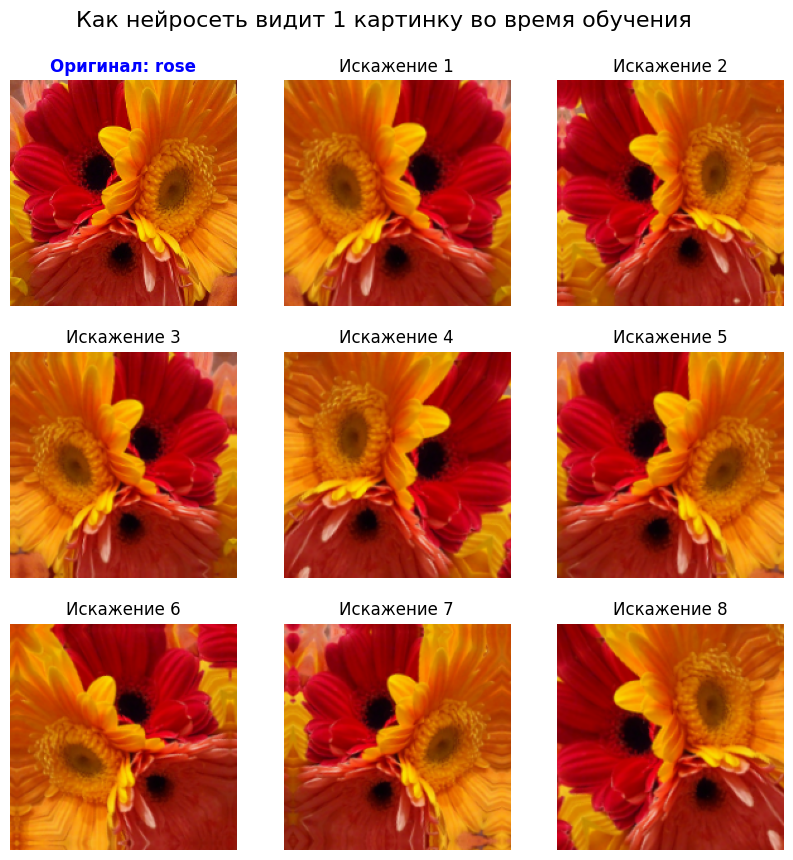

In [16]:

print("Демонстрация работы Data Augmentation (Аугментации данных)\n")

# Берем 1 случайный батч (пакет) из тренировочной выборки
for images, labels in train_ds.take(1):
    # Выбираем самую первую картинку из этого батча
    single_image = images[0]
    single_label = class_names[labels[0]]
    break

# Настраиваем размер холста
plt.figure(figsize=(10, 10))

# Выводим оригинальную картинку по центру (или первой) для сравнения
plt.subplot(3, 3, 1)
plt.imshow(single_image.numpy().astype("uint8"))
plt.title(f"Оригинал: {single_label}", color="blue", fontweight='bold')
plt.axis("off")

# Генерируем 8 искаженных вариантов этой же картинки
for i in range(1, 9):
    # Пропускаем картинку через наш слой аугментации
    # training=True обязательно, иначе аугментация "выключена"
    augmented_image = data_augmentation(tf.expand_dims(single_image, 0), training=True)
    
    # Отрисовываем результат
    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_image[0].numpy().astype("uint8"))
    plt.title(f"Искажение {i}")
    plt.axis("off")

plt.suptitle(f"Как нейросеть видит 1 картинку во время обучения", fontsize=16, y=0.95)
plt.show()

c:\Users\HUAWEI\AppData\Local\Programs\Python\Python311\Lib\site-packages\visualkeras\layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


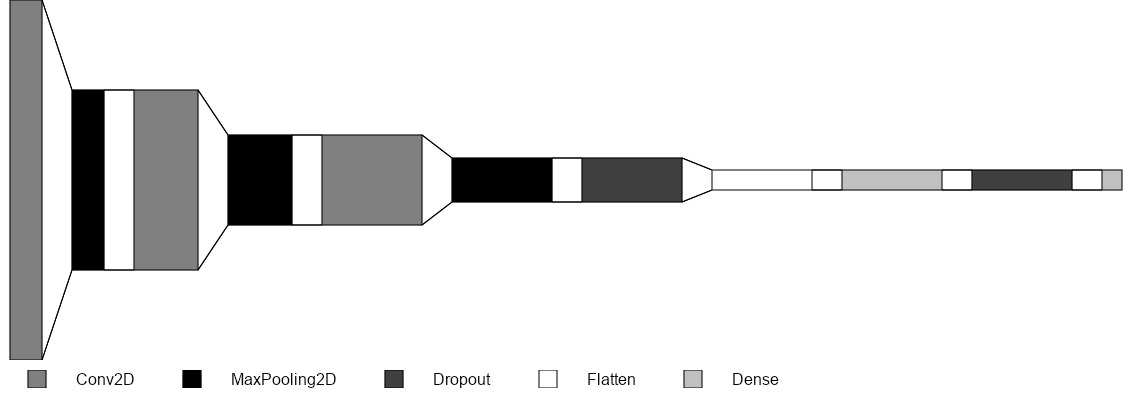

In [17]:

# Хак для обхода ограничений Keras 3 (возвращаем слоям их output_shape)
for layer in model.layers: 
    try:
        if hasattr(layer, 'output'): 
            layer.output_shape = layer.output.shape
    except AttributeError: 
        pass

# Настраиваем строгий черно-бело-серый стиль для блоков
color_map = defaultdict(dict)
color_map[tf.keras.layers.Conv2D]['fill'] = '#808080'      
color_map[tf.keras.layers.MaxPooling2D]['fill'] = '#000000' 
color_map[tf.keras.layers.Dropout]['fill'] = '#404040'     
color_map[tf.keras.layers.Flatten]['fill'] = '#FFFFFF'     
color_map[tf.keras.layers.Dense]['fill'] = '#C0C0C0'       

# Загружаем шрифт для подписей (для Windows arial.ttf встроен в систему)
try:
    font = ImageFont.truetype("arial.ttf", 16)
except:
    font = ImageFont.load_default()

# Прячем неинформативные слои (аугментацию и нормализацию), оставляем только "мозг" сети
ignore_layers = [
    tf.keras.Sequential,         
    tf.keras.layers.Rescaling,   
    tf.keras.layers.RandomFlip,  
    tf.keras.layers.RandomRotation,
    tf.keras.layers.RandomZoom
]

# Создаем блочную визуализацию
# draw_volume=False делает строгие прямоугольные блоки, True - объемные 3D
img_bw = visualkeras.layered_view(
    model, 
    to_file='model_architecture_blocks.png', 
    legend=True, 
    color_map=color_map,
    font=font, 
    spacing=30,             # Расстояние между блоками
    scale_xy=2,             # Масштаб блоков
    scale_z=1,
    max_z=100,
    draw_volume=False,      # Делаем прямоугольники плоскими (как вы и хотели)
    type_ignore=ignore_layers
)

# Выводим картинку на экран
img_bw

Epoch 1/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 32s 414ms/step - accuracy: 0.3295 - loss: 1.5049 - val_accuracy: 0.4479 - val_loss: 1.3561
Epoch 2/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 30s 433ms/step - accuracy: 0.4684 - loss: 1.2401 - val_accuracy: 0.5625 - val_loss: 1.1438
Epoch 3/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 28s 402ms/step - accuracy: 0.5403 - loss: 1.1266 - val_accuracy: 0.5347 - val_loss: 1.2102
Epoch 4/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 27s 398ms/step - accuracy: 0.5835 - loss: 1.0444 - val_accuracy: 0.5903 - val_loss: 1.0556
Epoch 5/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 28s 411ms/step - accuracy: 0.6076 - loss: 0.9810 - val_accuracy: 0.5417 - val_loss: 1.2290
Epoch 6/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 28s 399ms/step - accuracy: 0.6368 - loss: 0.9384 - val_accuracy: 0.6667 - val_loss: 1.0133
Epoch 7/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 27s 395ms/step - accuracy: 0.6459 - loss: 0.8821 - val_accuracy: 0.6562 - val_loss: 0.9096
Epoch 8/40
69/69 ━━━━━━━━━━━━━━━━━━━━ 27s 395ms/step - accuracy: 0.6595 - loss: 0.8460 - val_accu

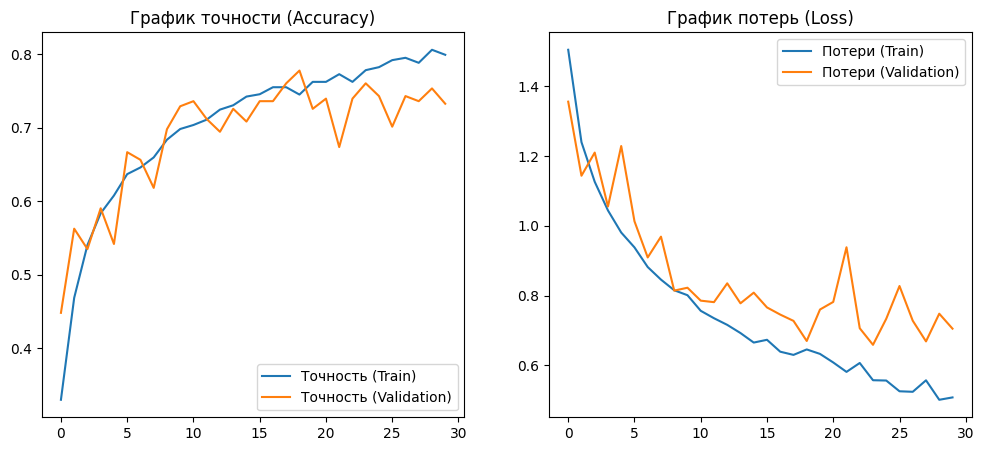

In [18]:
# 3. ОБУЧЕНИЕ И ГРАФИКИ
class VisualisePredictionsCallback(tf.keras.callbacks.Callback):
    def __init__(self, dataset, class_names):
        super().__init__()
        self.class_names = class_names
        self.images, self.labels = next(iter(dataset.take(1)))

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 5 == 0: 
            clear_output(wait=True)
            print(f'\n=== Предсказания нейросети после {epoch + 1} эпохи ===')
            predictions = self.model.predict(self.images, verbose=0)
            
            plt.figure(figsize=(10, 10))
            for i in range(9):
                plt.subplot(3, 3, i + 1)
                plt.imshow(self.images[i].numpy().astype("uint8"))
                pred_class = self.class_names[np.argmax(predictions[i])]
                actual_class = self.class_names[self.labels[i]]
                color = 'green' if pred_class == actual_class else 'red'
                plt.title(f'Сеть: {pred_class} | Факт: {actual_class}', color=color)
                plt.axis('off')
            plt.show()

# Умная остановка (EarlyStopping) предотвратит переобучение
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=6, 
    restore_best_weights=True
)

# Обучаем модель 
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=40, 
  callbacks=[early_stop]  # <-- Убрали визуализатор отсюда
)

# Рисуем графики точности и потерь
acc, val_acc = history.history['accuracy'], history.history['val_accuracy']
loss, val_loss = history.history['loss'], history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Точность (Train)')
plt.plot(epochs_range, val_acc, label='Точность (Validation)')
plt.legend(loc='lower right')
plt.title('График точности (Accuracy)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Потери (Train)')
plt.plot(epochs_range, val_loss, label='Потери (Validation)')
plt.legend(loc='upper right')
plt.title('График потерь (Loss)')
plt.show()

Сбор данных для матрицы ошибок


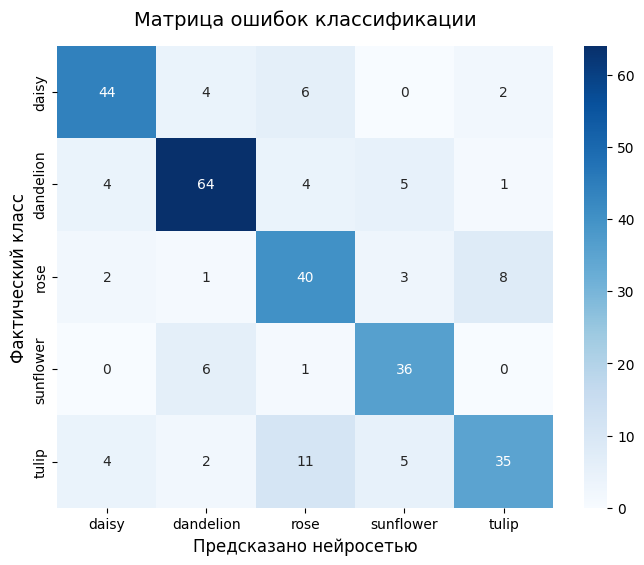

In [19]:
print("Сбор данных для матрицы ошибок")
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6), dpi=100)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Предсказано нейросетью', fontsize=12)
plt.ylabel('Фактический класс', fontsize=12)
plt.title('Матрица ошибок классификации', fontsize=14, pad=15)
plt.show()

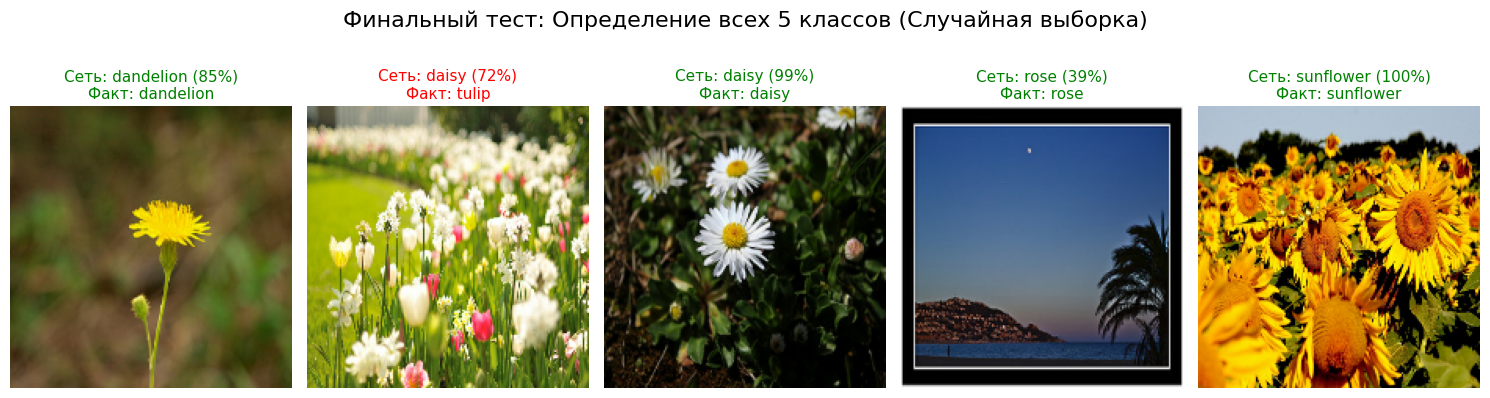


Модель успешно сохранена в файл 'offline_flowers_model.keras'


In [20]:
found_classes = set()
plt.figure(figsize=(15, 4))
plot_idx = 1

# Добавлено перемешивание (shuffle), чтобы каждый запуск выдавал разные картинки
for images, labels in test_ds.unbatch().shuffle(1000, reshuffle_each_iteration=True).batch(32):
    # Делаем предсказания для случайного пакета
    predictions = model.predict(images, verbose=0)
    
    for i in range(len(images)):
        actual_class = class_names[labels[i].numpy()]
        
        # Если мы еще не показывали картинку этого класса
        if actual_class not in found_classes:
            found_classes.add(actual_class)
            
            # Находим, что предсказала сеть
            pred_class = class_names[np.argmax(predictions[i])]
            confidence = 100 * np.max(predictions[i])
            
            # Отрисовываем картинку
            plt.subplot(1, 5, plot_idx)
            plt.imshow(images[i].numpy().astype("uint8"))
            
            # Зеленый текст если угадали, красный если ошиблись
            color = "green" if pred_class == actual_class else "red"
            plt.title(f"Сеть: {pred_class} ({confidence:.0f}%)\nФакт: {actual_class}", color=color, fontsize=11)
            plt.axis("off")
            plot_idx += 1
            
        # Как только нашли по одному фото для всех 5 классов - останавливаемся
        if len(found_classes) == 5:
            break
            
    if len(found_classes) == 5:
        break

plt.suptitle("Финальный тест: Определение всех 5 классов (Случайная выборка)", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

# Сохранение модели
model.save('offline_flowers_model.keras')
print("\nМодель успешно сохранена в файл 'offline_flowers_model.keras'")

In [21]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)

# Выводим результат в красивом виде
print(f"\nРезультаты тестирования:")
print(f"Точность (Accuracy): {test_accuracy * 100:.2f}%")
print(f"Ошибка (Loss):       {test_loss:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.7395 - loss: 0.6747

Результаты тестирования:
Точность (Accuracy): 73.95%
Ошибка (Loss):       0.6747


In [22]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 180, 180, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 90, 90, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 90, 90, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 45, 45, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 61952)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,929,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,071,633 (91.83 MB)

 Trainable params: 8,023,877 (30.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 16,047,756 (61.22 MB)

In [23]:
# 1. Сначала сохраняем обученную модель
model.save('offline_flowers_model.keras')
print("Модель сохранена на диск!")

import netron

# 3. Запускаем локальный сервер Netron
netron.start('offline_flowers_model.keras', browse=True)

Serving 'offline_flowers_model.keras' at http://localhost:8080


Модель сохранена на диск!


('localhost', 8080)